# Univariate Analysis

*Univariate analysis* involves observations consisting of only one variable. Since there is no relationship or dependency to explore, it is the simplest and most straightforward form of statistical analysis.

- Measures central tendency (mean, median, mode) to find the typical value.
- Measures dispersion (range, variance, standard deviation) to see how data spreads.
- Detects patterns like skewness or outliers that affect data interpretation.
- Common visuals include histograms, box plots and density plots to show frequency and spread.

In [136]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

## Meet the Palmer penguins

**Example**: we will demonstrate using datasets accessible from the seaborn library. Once you call `load_dataset`, it will load it into a DataFrame.

In [137]:
penguins = sns.load_dataset('penguins')
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


Dataset reference: [Palmer Penguins](https://allisonhorst.github.io/palmerpenguins/).

![](../assets/lter_penguins.png){height=400}

## Distribution Plots (`sns.displot()`)

The **Distribution** of a variable is the frequencies of its values.

- **Bar plot** is used to show **cateogrical** variable distribution
    - Example: `island` value counts are drawn as bars
- **Histogram** is used to show **numerical** variable distribution
    - Example: `body_mass_g` values are binned/grouped and counted using bars as well

### Bar plot

Statistics starts with **Counts**; the number of subjects with a certain characteristic.

Example is the `value_counts()`, summarizing the count of each value in the variable column:

In [138]:
penguins['island'].value_counts()

island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64

But we could also visualize it:

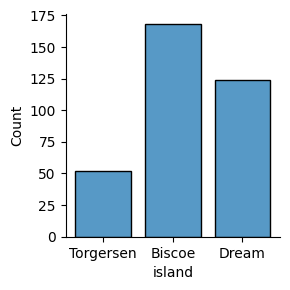

In [139]:
sns.displot(
    data=penguins,
    kind='hist', # Histogram
    discrete=True, shrink=0.8, # Categorical
    x='island', # Variable to plot on the x-axis
    height=3, aspect=1 # Figure size
)

#### Proportions

When ccounts are relative to the whole, it is called **Proportion** ($\hat p$) or *Relative Frequency* and is often expressed in precentage (%).

$$
\hat{p} = \frac{n}{N}
$$

We can show this using `value_counts` with `normalize=True`, like so:

In [140]:
penguins['island'].value_counts(normalize=True)

island
Biscoe       0.488372
Dream        0.360465
Torgersen    0.151163
Name: proportion, dtype: float64

It can be expressed in seaborn `displot` by setting `stat="probability"`:

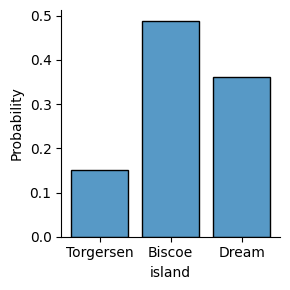

In [141]:
sns.displot(
    data=penguins,
    kind='hist',
    discrete=True, shrink=0.8,
    x='island',
    height=3, aspect=1,
    stat='probability'  # Shows relative frequency
)

Notice how the bars are always proportional whether we are using counts or frequencies on the y-axis.

#### Include more categorical variables with `hue`

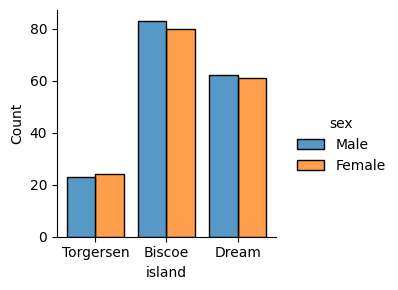

In [142]:
sns.displot(
    data=penguins,
    kind='hist',
    discrete=True, shrink=0.8,
    height=3, aspect=1,
    
    x='island',
    hue='sex',        # Distinguish color by this categorical variable
    multiple='dodge', # Put next to each other (try: "stack" and "fill")
)

#### Include more categorical variables with `col` and `row`

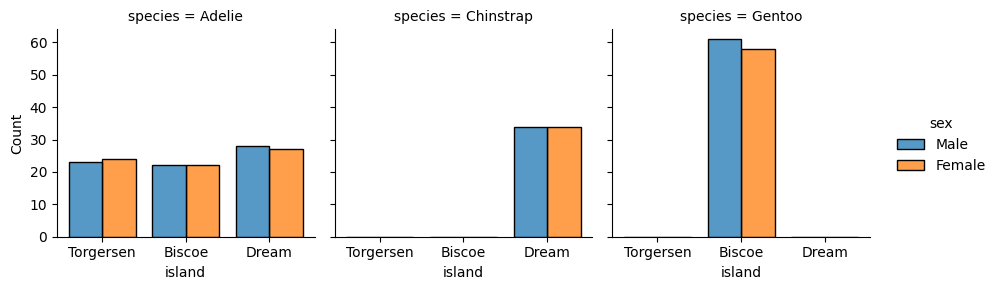

In [143]:
sns.displot(
    data=penguins,
    kind='hist',
    discrete=True, shrink=0.8,
    height=3, aspect=1,
    
    x='island',
    hue='sex',
    multiple='dodge',
    col='species',    # Try row instead of col
)

### Histogram

**Histogram** shows where the values of the variable `body_mass_g` lie on the x-axis, and how many of them are there (count).

Let's look at the value counts of height in meters `body_mass_g` (numerical):

In [161]:
counts = penguins['body_mass_g'].value_counts()
counts

body_mass_g
3800.0    12
3700.0    11
3950.0    10
3900.0    10
3550.0     9
          ..
5450.0     1
4975.0     1
4575.0     1
4375.0     1
5750.0     1
Name: count, Length: 94, dtype: int64

#### Binning

A histogram groups the values into **Bins** of uniform size before drawing the bar which represents how many values is in that bin.

In [164]:
bins = pd.cut(penguins['body_mass_g'], bins=10)
bin_counts = bins.value_counts().sort_index()
bin_counts

body_mass_g
(2696.4, 3060.0]    15
(3060.0, 3420.0]    43
(3420.0, 3780.0]    71
(3780.0, 4140.0]    53
(4140.0, 4500.0]    45
(4500.0, 4860.0]    38
(4860.0, 5220.0]    28
(5220.0, 5580.0]    27
(5580.0, 5940.0]    16
(5940.0, 6300.0]     6
Name: count, dtype: int64

From seaborn, we select a `displot` (distribution plot) of `kind='hist'`:

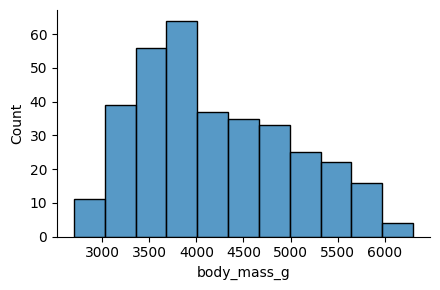

In [166]:
sns.displot(
    penguins, kind='hist',
    x='body_mass_g',
    aspect=1.5, height=3
)

**Histograms** are used to answer many important questions:

1. What **range** do the observations cover?
2. What is their **center**?
3. Are they heavily **skewed** in one direction?
4. Is there evidence for **bimodality**?
5. Are there significant **outliers**?
6. Do the answers to these questions vary **across subsets** defined by other variables?


You may choose to adjust the size / number of bins in two ways:

- By Width: `binwidth=10`
- By Count: `bins=20`

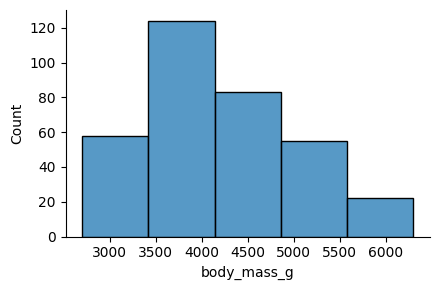

In [175]:
sns.displot(
    penguins, kind='hist',
    x='body_mass_g',
    aspect=1.5, height=3,

    # binwidth=100, # by width
    bins=5,      # or by count
)


#### KDE Plot

Sometimes we use the **Kernel Density Estimation plot** (KDE) instead to show the distrubtion:

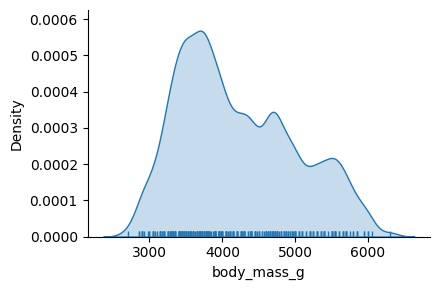

In [193]:
sns.displot(
    penguins,
    x='body_mass_g',
    aspect=1.5, height=3,
    
    kind='kde',     # Curve
    fill=True,      # Fill-in with color
    rug=True,       # Show actual where samples are
    bw_adjust=0.45  # Curve smoothness
)

**Bimodality**: we observe the shape showing multiple peaks, suggesting a mixure of distributions, which we can split using `hue`:

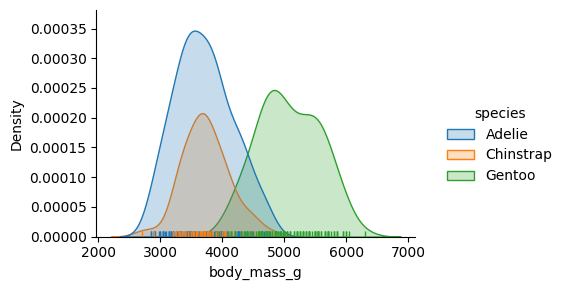

In [92]:
sns.displot(
    penguins,
    kind='kde',
    fill=True,
    rug=True,
    aspect=1.5, height=3,

    x='body_mass_g', # Numerical
    hue='species',   # Categorical
)

It is also possible to draw each individual distribution in a separate subplot: by assigning the second variable to `col` or `row` rather than (or in addition to) `hue`:

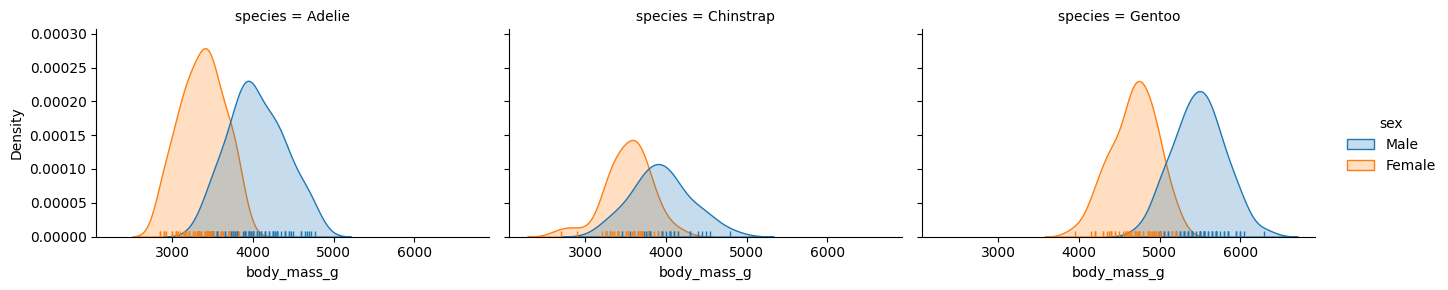

In [93]:
sns.displot(
    penguins,
    kind='kde', fill=True, rug=True,
    aspect=1.5, height=3,
    
    x="body_mass_g", # Numerical
    hue="sex",       # Cateogrical
    col="species",   # Categorical
)

## Distribution Statistics (`df.describe()`)

We describe a distribtuion by three properties:

1. **Central Tendency**
2. **Dispersion**
3. **Skewness**

### 1. Central Tendency

 1. **Mode**: the most frequent value.
 2. **Median**: the middle value when data are ordered.
 3. **Mean** (average): the center of "mass" ($\bar{x}$ or $\mu$).

The mean ($\mu$) is the sum of the values divided by their count:

$$
\mu = \frac{1}{N}\sum_{i=1}^{N} x_i
$$

- $\mu$ denotes population mean
- $N$ is the count

### 2. Dispersion

  1. **Range**: the difference between the maximum and minimum values.
  2. **Variance**: the average of the squared differences from the mean ($\sigma^2$).
  3. **Standard Deviation**: the square root of the variance ($\sigma$).

The variance ($\sigma^2$) is described mathematically as:

$$
\sigma^2 = \frac{1}{N}\sum_{i=1}^{N}(x_i - \mu)^2
$$

In a physical sense, we can see:

- the variance being the spread of the mass
- the mean being the center of the mass

![Physical Metaphor](../../assets/variance_physical_metaphor.png)

In Pandas, we simply call the `describe` method on the column (series), to get all these statistics:

In [195]:
penguins['body_mass_g'].describe()

count     342.000000
mean     4201.754386
std       801.954536
min      2700.000000
25%      3550.000000
50%      4050.000000
75%      4750.000000
max      6300.000000
Name: body_mass_g, dtype: float64

Note the following:

- The `std` is the standard deviation
- The `50%` percentile is the **median** statistic.
- The **range** is shown by the **max** and **min** statistics.
- The **mode** is more useful when we are looking at categorical attribute. In our case, the attribute is numerical.

### Percentiles

The **median** is the 50th percentile (`50%`) which means that 50% of the data points are below this value.

The `25%` and the `75%` percentiles go by other names:
  - the 1st and 3rd quartiles
  - the Q1 and Q3
  - the lower and upper quartiles

### 3. Skewness

We get skewness when the distribution is **not symmetric**:

- The *Mode* is the peak
- The *Mean* pulls the curve downwards
- The *Median* follows the mean a little bit

![Skewness](../../assets/skewness.png){height=480}

This can be calculated using the `.skew()` method where:

- `0` Perfectly Symmetrical (Normal).
- `>0` Right-skewed: Long tail on the right side.
- `<0` Left-skewed: Long tail on the left side.

In [198]:
penguins['body_mass_g'].skew()

np.float64(0.470329330480123)

## The Normal Distribution

The **Normal Distribution** (or **Gaussian Distribution**) is a bell-shaped distribution that is symmetric around the mean, with the highest density of data points in the center.

![The Normal Distribution](../../assets/normal_distribution.png){height=550}

In a perfect Gaussian distribution, data is distributed with mathematical precision. This is often called the **Empirical Rule**:

| **Distance from Mean**                   | **Percentage of Data Included** |
| ---------------------------------------- | ------------------------------- |
| Within $1\sigma$ | **68.2%**                       |
| Within $2\sigma$ | **95.4%**                       |
| Within $3\sigma$ | **99.7%**                       |

### Example 1 (Interactive): Standardized Test Scores

Exams like the SAT or IQ tests are specifically **designed** so that the results fall into a normal distribution, allowing scorers to see how an individual compares to the "average" ($\mu$).

iIf students in a math class took a final exam, and the class average was 7.5 out of 10 and the standard deviation was 0.5 points. If the class scores follow a normal distribution, then this means that:

- 68% of the students received a score between 7.0 and 8.0 on the test, or the mean (7.5) plus or minus 1 standard deviation (0.5)
- 95% of students received a grade between 6.5 and 8.5 on the exam, or the mean (7.5) plus or minus 2 standard deviations (1.0)
- 99.7% of students received a grade between 6.0 and 9.0, or the mean (7.5) plus or minor 3 standard deviations

**The following is an interactive example which you can try out to play with the normal distribution**:

- Changing the `mean` would move the `median`, `min` and `max` statistics with it, but won't have an effect on the `range` statistic.
- Changing the `std` would affect the `min` and `max` statistics and consequently, the `range` statstic, but won't have an effect on the `median`.

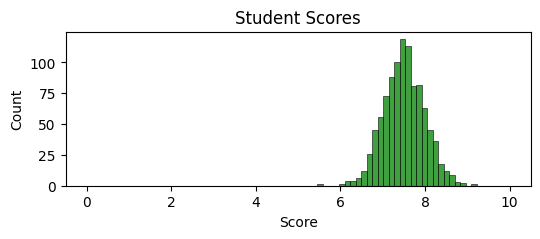

In [ ]:
# Generate data
scores = np.random.normal(
    loc=7.5,   # Mean               <<----- CHANGE THIS
    scale=0.5, # Standard Deviation <<----- CHANGE THIS
    size=1000  # Number of observations
)
df = pd.DataFrame(scores, columns=['Score'])

# Plot
fig, ax = plt.subplots(figsize=(6, 2))
sns.histplot(df['Score'], binrange=(0, 10), color='green')
ax.set(title="Student Scores");

**Try and Observe**: try changing the mean and standard deviation in the above code to see how normal curve behaves.

### Example 2: Human Heights and Weights

[Human Heights and Weights Dataset Source](https://www.kaggle.com/datasets/burnoutminer/heights-and-weights-dataset).

In [ ]:
# Load dataset
humans = pd.read_csv("../../data/SOCR-HeightWeight.csv")

# Convert units
humans["Height (m)"] = humans["Height(Inches)"] * 0.0254
humans["Weight (kg)"] = humans["Weight(Pounds)"] * 0.4535924

# Drop old values
humans = humans.drop(columns=["Height(Inches)", "Weight(Pounds)"])

# Summary statistics
humans.describe()

,Index,Height (m),Weight (kg)
count,25000.000000,25000.000000,25000.000000
mean,12500.500000,1.727025,57.642260
std,7217.022701,0.048303,5.289295
min,1.000000,1.531070,35.386902
25%,6250.750000,1.694292,54.117508
50%,12500.500000,1.727091,57.677789
75%,18750.250000,1.759533,61.186372
max,25000.000000,1.908881,77.529827


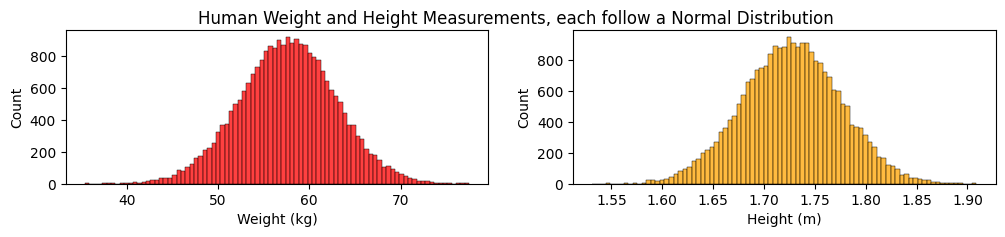

In [ ]:
fig, ax = plt.subplots(ncols=2, figsize=(12, 2))

fig.suptitle("Human Weight and Height Measurements, each follow a Normal Distribution")
sns.histplot(humans, x="Weight (kg)", color="red", ax=ax[0]);
sns.histplot(humans, x="Height (m)", color="orange", ax=ax[1]);

### Example 3: Comparative IQ Distribution

In [ ]:
# | echo: false
# | code-fold: true

from scipy.stats import norm

# Generate x and y
mean_iq = 100
std_dev_women = 13.2  # Lower variance (taller, narrower curve than men)
std_dev_men = 16.2    # Higher variance (shorter, wider curve)
x_min = 60
x_max = 140

x = np.linspace(x_min, x_max, 1000)
y_men = norm.pdf(x, loc=mean_iq, scale=std_dev_men)
y_women = norm.pdf(x, loc=mean_iq, scale=std_dev_women)

**What do you observe about the two overlapping distributions?**

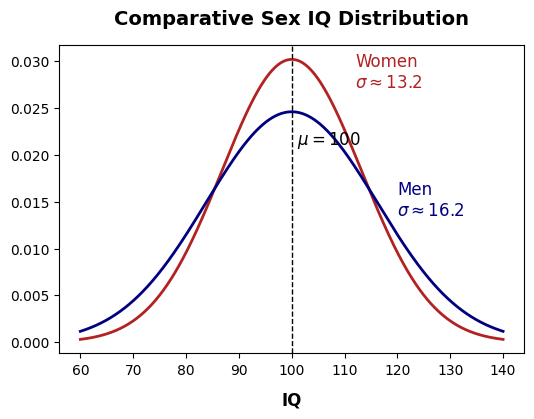

In [ ]:
# | echo: false
# | code-fold: true

# Plot the curves matching the visual colors
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x, y_women, color='firebrick', linewidth=2)
ax.plot(x, y_men, color='navy', linewidth=2)

# Vertical line for the mean
ax.axvline(mean_iq, color='black', linestyle='--', linewidth=1)
ax.text(mean_iq + 1, max(y_women)*0.70, f'$\\mu={mean_iq}$', color='black', fontsize=12)

# Add text labels directly onto the plot (coordinates manually adjusted for fit)
ax.text(112, max(y_women)*0.90, 'Women\n$\\sigma\\approx{}$13.2', 
        color='firebrick', fontsize=12)
ax.text(120, max(y_men)*0.55, 'Men\n$\\sigma\\approx{}$16.2', 
        color='navy', fontsize=12)

# 5. Formatting to match the original image's clean style
ax.set_title('Comparative Sex IQ Distribution', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('IQ', fontsize=12, fontweight='bold', labelpad=10)

# Set the specific x-axis tick marks
ax.set_xticks(range(x_min, x_max+1, 10));

The figure above shows two **Normal** distributions:

1. with the same **Mean** (center)
2. but different **Standard Deviation** (dispersion).

**Common Misconception**: People often see the red curve is much taller and mistakenly conclude that: "**there are more women in the dataset than men**". Wrong! In reality, the area under the curve represents the total population, not the height of the peak.

Notice that both the red curve (Women) and the blue curve (Men) peak at the same point on the x-axis (IQ ≈ `100`). This indicates that the **mean**, **median**, and **mode** for both groups are approximately equal.

Because the **variance** for men is roughly `5%` to `15%` larger than it is for women, the male distribution curve is wider and flatter, while the female distribution curve is taller and narrower around the middle.

- The Middle: Women are more heavily clustered around the dead-center average (the `85` to `115` IQ range).
- The Extremes: Men are overrepresented at both extremes of the bell curve.

If you look at the extreme right tail of the distribution (an IQ of `140` or higher), the wider male variance means there is a higher ratio of men to women. Conversely, if you look at the extreme left tail (an IQ of `60` or lower), there is also a significantly higher ratio of men to women experiencing severe cognitive deficits.

### Other Examples of the Normal Distribution

Many other things in life follow the same distribution:

- **Biological Measurements**:
    - height
    - blood pressure
    - leaf lengths on a tree
    - birth weight of newborns
- **Manufacturing Errors**: If a machine is set to cut `10cm` bolts, most will be exactly `10cm`. A few will be `10.01cm`, and a few `9.99cm`. Extremely rare outliers might be `10.1cm`.

## Outliers: far from normal

An **Outlier** is an observation which deviates **"too much"** from other observations. Since statistical models look at the group, members that aren't likely of the same group distort these models and affect our calculated statistics, especially when the outliers are exterme and numerous.

We **don't automatically remove** these values, rather, we might want to inspect further to know more about their story.

Deciding how much is "too much" can be done many ways:

1. The **Z-Score method**
2. The **IQR method**
3. others..

### 1. Z-Score Method

The most common one that works well with the *Normal Distribution* is the **Z-score method**, which is calculated by subtracting the mean and dividing by the standard deviation:

$$
z = \frac{x-\mu}{\sigma}
$$

Where:

- $\mu$ is the mean
- $\sigma$ is the standard deviation

The z-score is also interpreted as:

1. centering around the mean
2. adjusting by the standard deviation

Then, we consider *abnormal* what lies after three standard units from the mean:

$$
z \lt -3 \\ 
z \gt +3
$$

More succiently:

$$ \text{Outlier if:} \vert z \vert \gt 3 $$

Let's do it in code:

In [ ]:
def z_score(series: pd.Series):
    return (series - series.mean()) / series.std()

Each `body_mass_g` value now is mapped to a standard value (z-score):

In [382]:
humans['z_score'] = z_score(humans['Height (m)'])
humans[['Height (m)', 'z_score']].sort_values(by=['z_score'], ascending=[True])

,Height (m),z_score
13971,1.531070,-4.056812
2651,1.539561,-3.881025
20608,1.544477,-3.779247
5641,1.545930,-3.749168
12031,1.546092,-3.745819
...,...,...
15209,1.894838,3.474202
13681,1.898408,3.548105
16752,1.901162,3.605123
2481,1.907926,3.745152


How many outliers do we have? (considering the z-score method)

In [393]:
cond1 = humans['z_score'] > 3
cond2 = humans['z_score'] < -3
num_z_score_outliers = humans[cond1 | cond2].shape[0]
print(num_z_score_outliers)

51


If we plot the distribution of both, we won't see any difference in the shape:

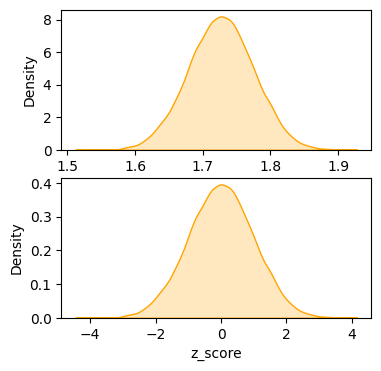

In [386]:
fig, ax = plt.subplots(2, 1, figsize=(4, 4))

sns.kdeplot(humans['Height (m)'], fill=True, ax=ax[0], color='orange')
sns.kdeplot(humans['z_score']    , fill=True, ax=ax[1], color='orange')

plt.show()

### 2. IQR Method

By convention, a data point may be considered to be an *outlier* if it lies outside of the **Inter-quartile range (IQR)** by more than 1.5 times the IQR. i.e.:

$$
x < Q_1 - 1.5 \times \text{IQR}\\
x > Q_3 + 1.5 \times \text{IQR}
$$

![Box and Whiskers Plot](../../assets/box-and-whiskers_plot.png)

### Box-and-whiskers Plot

A [**boxplot**](https://www.data-to-viz.com/#boxplot) gives a nice summary of one or several numeric variables. The line that divides the box into 2 parts represents the median of the data. The end of the box shows the upper and lower quartiles. The extreme lines show the highest and lowest value excluding outliers.

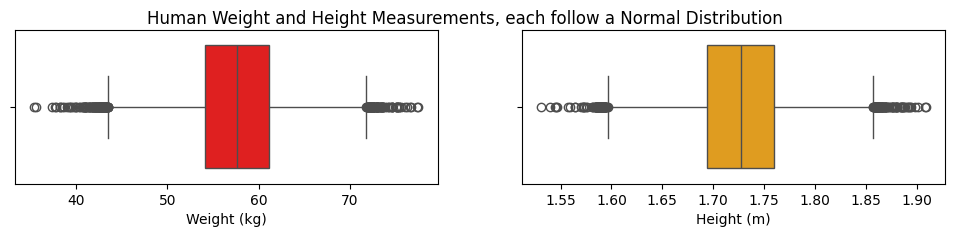

In [373]:
fig, ax = plt.subplots(ncols=2, figsize=(12, 2))

fig.suptitle("Human Weight and Height Measurements, each follow a Normal Distribution")
sns.boxplot(humans, x="Weight (kg)", color="red", ax=ax[0]);
sns.boxplot(humans, x="Height (m)", color="orange", ax=ax[1]);

In [397]:
q1 = humans['Height (m)'].quantile(0.25)
q3 = humans['Height (m)'].quantile(0.75)
iqr = q3 - q1
lower_whisker = q1 - 1.5*iqr
uppwer_whisker = q3 + 1.5*iqr

How many outliers do we have? (considering the IQR method?)

In [399]:
cond1 = humans['Height (m)'] > uppwer_whisker
cond2 = humans['Height (m)'] < lower_whisker
num_iqr_outliers = humans[cond1 | cond2].shape[0]

In [401]:
print("Z-score outliers:", num_z_score_outliers)
print("    IQR outliers:", num_iqr_outliers)

Z-score outliers: 51
    IQR outliers: 167


### Comparing IQR & Z-score methods

We notice that the IQR-method is more conservative; i.e., **flags more outliers** compared to the z-score method.

![](../assets/boxplot_vs_normal.png)

## Interpreting Comparative Distributions

Let's go back to our comparison: NBA Players vs General Public in terms of Height.

Below are the distributions of height in centimeters across:

- Adult women globally (mean of `159cm` and standard deviation of `6cm`)
- Adult men globally (mean of `171cm` and standard deviation of `7cm`)
- NBA players; a specific subset of adult men (~2300 players who have been part of an NBA team roster between 1996 and 2019)

Let's visualize it:

![Comparative Distribution of NBA Player's Heights and Human Heights. Image Source: https://distributionofthings.com/human-height/](../../assets/nba_comparative_distribution.png)


The figure above shows

- three **Normal** distributions
- with increasing centers (as we go right)
- and decreasing dispersino (as we go right)

Using statistics we can make **General Statements** like:

1. "men are taller than women" (on average is implied)
2. "most NBA players are taller than most people"
3. "most NBA players are men"
4. "very few women are taller than the shortest NBA players"

Notice that since there are overlaps, we can't give **Definitive Statements** like:

- "All men are ... " (confirmatory)
- "No Player is ..." (negation)

### Interpreting Outliers

When having outliers in one distribution, that might signal to us that it is, in fact, a member of another distribution. In this case:

- a Male with a height of `+192cm` might be an **outlier within Males**, but
- that's within the normal distribution of **NBA Players**

If you want to read more about human height, its evolution across the world and predictions for the future I encourage you to check out this great [article from Our World in Data](https://ourworldindata.org/human-height).

## Variations of Distribution Plots

### Variation 1: Mirror Histogram

A common variation of the histogram is the [**mirror histogram**](https://python-graph-gallery.com/density-mirror/): it puts face to face 2 histograms to compare their distribution.

![](../assets/population_pyramid.png)

See: [Population Pyramid | DataSaudi.sa](https://datasaudi.sa/en#population-pyramid)

### Variation 2: Ridgeline Plot

A [**Ridgeline plot**](https://www.data-to-viz.com/graph/ridgeline.html) (sometimes called **Joyplot**) shows the distribution of a numeric value for several groups. Distribution can be represented using histograms or density plots, all aligned to the same horizontal scale and presented with a slight overlap.

![Ridge Plot of Temperature in Lincoln NE in 2016](../../assets/ridgeplot_temperature_in_lincoln_ne_in_2016.png){height=480}

## Other Distributions

![Histogram Distributions](../../assets/histogram_distributions.png){height=600}

We describe the distribtuion using these vocabularies:

1. Normal: symmetric triangle
2. Uniform: even, like a brush
3. Left-skewed: right-angle triangle
4. Right-skewed: left-angle triangle
5. Bimodal: two normals together
6. Multi-modal: many normals together

### Example: Exponential Distribution

Distrubtion of Death by Age in Australia in the Year 2012.

![Deaths in Australia in the year 2012](../../assets/deaths-in-australia-in-the-year-2012.png){height=480}


The figure above shows a **left-tailed exponential distribution**.

The graph shows "Deaths in Australia in the year 2012." This is an excellent example of a **Negatively Skewed (Left-Skewed)** distribution.

* **Direction of Skew:** A distribution is named by the direction of its "tail." Here, the tail extends toward the younger age brackets (the left). This indicates that while most people die at older ages, a smaller number of "outliers" die much younger, pulling the average down.
* **The Relationship Between Mean, Median, and Mode:** In a perfectly symmetrical curve, these three would be the same. However, in a skewed distribution, they pull apart:
    * **Mode (~87 years):** The "most frequent" age of death, represented by the highest peak.
    * **Median (~81 years):** The middle value; 50% of people died before this age, and 50% after.
    * **Mean (~77 years):** The arithmetic average. It is the most affected by the "tail." Because some people die very young (ages 0–40), the mean is pulled significantly lower than the mode.
* **Insight:** When data is skewed, the **Median** is often a better "typical" representation of the data than the Mean, because the Mean is overly sensitive to extreme outliers (infant mortality or early-life accidents).

### Other Examples

See the blog: [**Distribution of Things**](https://distributionofthings.com/).